# Keypoint MoSeq for Home Cage SLEAP Data

This notebook uses the home-cage SLEAP organization already used in `Pose_Tracking`.

- TDT trial folders define `subject_name`
- SLEAP `.analysis.h5` files are matched by `subject_name`
- each SLEAP track (`subject`, `agent`) is exported as its own Keypoint MoSeq recording

The helper functions live in `keypoint_moseq_utils.py`.

In [2]:
import os
import sys
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "Keypoint_moseq_analysis":
    ANALYSIS_DIR = PROJECT_ROOT
elif (PROJECT_ROOT / "Keypoint_moseq_analysis").exists():
    ANALYSIS_DIR = PROJECT_ROOT / "Keypoint_moseq_analysis"
else:
    ANALYSIS_DIR = PROJECT_ROOT

if str(ANALYSIS_DIR) not in sys.path:
    sys.path.insert(0, str(ANALYSIS_DIR))

from keypoint_moseq_utils import (
    build_home_cage_dataset,
    filter_home_cage_recordings_to_valid_frames,
    load_kpms_inputs,
    results_to_frame_table,
    save_kpms_inputs,
)


In [3]:
import jax
print(jax.devices())


[CpuDevice(id=0)]


## Paths and Settings

Fill in the directories for your home-cage experiment.

In [4]:
experiment_dir = Path(r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Home_Cage\SLEAP\all_tdt")
behavior_dir = Path(r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Home_Cage\SLEAP\all_csvs")
sleap_dir = Path(r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Home_Cage\SLEAP\sleap_id_corrected_nayla_updates")
video_dir = Path(r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Home_Cage\SLEAP\HC_Videos_Only")
valid_frames_csv = POSE_TRACKING_DIR / "home_cage_pose_DA_all.csv"
project_dir = ANALYSIS_DIR / "keypoint_moseq_project_home_cage"

fps = 10.0
include_tracks = ("subject", "agent")

# Set True if you want each manual social bout exported as its own recording.
use_bouts = False

# Default bodypart handling for fitting.
exclude_bodyparts = []
anterior_bodyparts = ["Nose"]
posterior_bodyparts = ["Tail_Base"]

project_dir.mkdir(parents=True, exist_ok=True)
project_dir


Path('c:/Users/alber/OneDrive/Documents/GitHub/Fiber_Photometry_revisions/Pose_Tracking/keypoint_moseq_project_home_cage')

## Export Keypoint MoSeq Inputs

This reads the SLEAP files directly and packages them for Keypoint MoSeq.

In [13]:
coordinates, confidences, bodyparts, skeleton, metadata_df = build_home_cage_dataset(
    experiment_dir=str(experiment_dir),
    sleap_dir=str(sleap_dir),
    fps=fps,
    include_tracks=include_tracks,
    use_bouts=use_bouts,
    behavior_dir=str(behavior_dir) if use_bouts else None,
)

valid_frame_df = pd.read_csv(valid_frames_csv)
coordinates, confidences, metadata_df = filter_home_cage_recordings_to_valid_frames(
    coordinates,
    confidences,
    metadata_df,
    valid_frame_df,
)

inputs_path = project_dir / "home_cage_kpms_inputs_valid_frames.pkl"
metadata_path = project_dir / "recording_metadata_valid_frames.csv"

save_kpms_inputs(
    output_path=str(inputs_path),
    coordinates=coordinates,
    confidences=confidences,
    bodyparts=bodyparts,
    skeleton=skeleton,
    metadata_df=metadata_df,
)
metadata_df.to_csv(metadata_path, index=False)

print(f"Saved inputs to: {inputs_path}")
print(f"Saved metadata to: {metadata_path}")
print(f"Valid frame source: {valid_frames_csv}")
print(f"Recordings exported: {len(coordinates)}")
metadata_df.head()


Saved inputs to: c:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photometry_revisions\Pose_Tracking\keypoint_moseq_project_home_cage\home_cage_kpms_inputs_valid_frames.pkl
Saved metadata to: c:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photometry_revisions\Pose_Tracking\keypoint_moseq_project_home_cage\recording_metadata_valid_frames.csv
Valid frame source: c:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photometry_revisions\Pose_Tracking\home_cage_pose_DA_all.csv
Recordings exported: 50


,recording_name,subject_name,trial_name,track_name,source_h5,n_frames,fps,bout_name,bout_start_s,bout_end_s
0,n5_agent,n5,n5-240823-085032,agent,C:\Users\alber\OneDrive\Desktop\PC_Lab\Photome...,15058,10.0,None,None,None
1,n5_subject,n5,n5-240823-085032,subject,C:\Users\alber\OneDrive\Desktop\PC_Lab\Photome...,15058,10.0,None,None,None
2,n6_agent,n6,n6-240823-101436,agent,C:\Users\alber\OneDrive\Desktop\PC_Lab\Photome...,15071,10.0,None,None,None
3,n6_subject,n6,n6-240823-101436,subject,C:\Users\alber\OneDrive\Desktop\PC_Lab\Photome...,15071,10.0,None,None,None
4,n7_agent,n7,n7-240824-062103,agent,C:\Users\alber\OneDrive\Desktop\PC_Lab\Photome...,15093,10.0,None,None,None


In [6]:
sorted(bodyparts), skeleton[:10]


(['Center',
  'Head',
  'Left_Ear',
  'Left_Lateral',
  'Neck',
  'Nose',
  'Right_Ear',
  'Right_Lateral',
  'Tail_Base'],
 [['Tail_Base', 'Left_Lateral'],
  ['Tail_Base', 'Right_Lateral'],
  ['Tail_Base', 'Center'],
  ['Center', 'Right_Lateral'],
  ['Center', 'Left_Lateral'],
  ['Center', 'Neck'],
  ['Neck', 'Right_Lateral'],
  ['Neck', 'Left_Lateral'],
  ['Neck', 'Head'],
  ['Head', 'Nose']])

## Review the Exported Recordings

Each recording is a single animal track, optionally split by bout.

In [6]:
metadata_df.groupby(["track_name", "subject_name"]).agg(
    n_recordings=("recording_name", "count"),
    total_frames=("n_frames", "sum"),
).reset_index().head(20)


,track_name,subject_name,n_recordings,total_frames
0,agent,n5,1,15058
1,agent,n6,1,15071
2,agent,n7,1,15093
3,agent,nn1,1,15078
4,agent,nn2,1,15046
5,agent,nn3,1,15095
6,agent,nn4,1,15115
7,agent,nn5,1,15062
8,agent,nn6,1,15063
9,agent,nn7,1,15093


## Load Keypoint MoSeq

Run this only after installing `keypoint_moseq` in the Python environment backing this notebook.

In [7]:
import keypoint_moseq as kpms

payload = load_kpms_inputs(str(inputs_path))
coordinates = payload["coordinates"]
confidences = payload["confidences"]
bodyparts = payload["bodyparts"]
skeleton = payload["skeleton"]
metadata_df = payload["metadata_df"]

print(f"Loaded {len(coordinates)} recordings for Keypoint MoSeq")


Loaded 50 recordings for Keypoint MoSeq


## Set Up the Keypoint MoSeq Project

In [12]:
config_path = project_dir / "config.yml"

if not config_path.exists():
    print(f"No config found at {config_path}. Creating a default config first.")
    kpms.setup_project(
        str(project_dir),
        bodyparts=bodyparts,
        skeleton=skeleton,
        use_bodyparts=bodyparts,
        anterior_bodyparts=anterior_bodyparts,
        posterior_bodyparts=posterior_bodyparts,
        video_dir=str(video_dir),
        fps=fps,
        overwrite=True,
    )
else:
    print(f"Using existing config: {config_path}")

use_bodyparts = [bp for bp in bodyparts if bp not in exclude_bodyparts]
missing_anterior = [bp for bp in anterior_bodyparts if bp not in use_bodyparts]
missing_posterior = [bp for bp in posterior_bodyparts if bp not in use_bodyparts]

if missing_anterior or missing_posterior:
    raise ValueError(
        "Chosen anterior/posterior bodyparts must also be present in use_bodyparts. "
        f"Missing anterior: {missing_anterior}; missing posterior: {missing_posterior}"
    )

kpms.update_config(
    str(project_dir),
    bodyparts=bodyparts,
    skeleton=skeleton,
    video_dir=str(video_dir),
    anterior_bodyparts=anterior_bodyparts,
    posterior_bodyparts=posterior_bodyparts,
    use_bodyparts=use_bodyparts,
    fps=fps,
    latent_dim=10,
    num_states=75,
)

config = kpms.load_config(str(project_dir))
sigmasq_data, _ = kpms.format_data(coordinates, confidences, **config)
sigmasq_filter_size = max(1, int(round(config["fps"])))
sigmasq_loc = kpms.estimate_sigmasq_loc(
    sigmasq_data["Y"],
    sigmasq_data["mask"],
    filter_size=sigmasq_filter_size,
)
kpms.update_config(str(project_dir), sigmasq_loc=sigmasq_loc)
config = kpms.load_config(str(project_dir))
config


Using existing config: c:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photometry_revisions\Pose_Tracking\keypoint_moseq_project_home_cage\config.yml


{'bodyparts': ['Head',
  'Right_Ear',
  'Nose',
  'Tail_Base',
  'Left_Lateral',
  'Right_Lateral',
  'Left_Ear',
  'Neck',
  'Center'],
 'use_bodyparts': ['Head',
  'Right_Ear',
  'Nose',
  'Tail_Base',
  'Left_Lateral',
  'Right_Lateral',
  'Left_Ear',
  'Neck',
  'Center'],
 'skeleton': [['Tail_Base', 'Left_Lateral'],
  ['Tail_Base', 'Right_Lateral'],
  ['Tail_Base', 'Center'],
  ['Center', 'Right_Lateral'],
  ['Center', 'Left_Lateral'],
  ['Center', 'Neck'],
  ['Neck', 'Right_Lateral'],
  ['Neck', 'Left_Lateral'],
  ['Neck', 'Head'],
  ['Head', 'Nose']],
 'anterior_bodyparts': ['Nose'],
 'posterior_bodyparts': ['Tail_Base'],
 'added_noise_level': 0.1,
 'PCA_fitting_num_frames': 1000000,
 'conf_threshold': 0.5,
 'error_estimator': {'intercept': 0.25, 'slope': -0.5},
 'obs_hypparams': {'nu_s': 5,
  'nu_sigma': 100000.0,
  'sigmasq_0': 0.1,
  'sigmasq_C': 0.1},
 'ar_hypparams': {'K_0_scale': 10.0,
  'S_0_scale': 0.01,
  'latent_dim': 10,
  'nlags': 3},
 'trans_hypparams': {'alpha': 5.

## Optional Outlier Removal

In [9]:
run_outlier_removal = True

if run_outlier_removal:
    coordinates, confidences = kpms.outlier_removal(
        coordinates,
        confidences,
        str(project_dir),
        overwrite=False,
        **config,
    )


## Format Data and Fit PCA

In [10]:
data, metadata = kpms.format_data(coordinates, confidences, **config)
pca = kpms.fit_pca(**data, **config)
kpms.save_pca(pca, str(project_dir))
pca


,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,42


## Fit the Model

The two-stage fit below mirrors the command-line script setup.

In [ ]:
# import keypoint_moseq as kpms

# model_name = "2026_05_13-12_27_28"  # or whichever run crashed
# target_iter = 250  # 50 AR + 200 full
# model, data_ckpt, metadata_ckpt, current_iter = kpms.load_checkpoint(
#     str(project_dir),
#     model_name,
# )

# print("Resuming", model_name, "from iteration", current_iter)

# if current_iter < target_iter:
#     model = kpms.update_hypparams(model, kappa=1e4)  # match that run's full_kappa
#     model = kpms.fit_model(
#         model,
#         data_ckpt,
#         metadata_ckpt,
#         str(project_dir),
#         model_name,
#         ar_only=False,
#         start_iter=current_iter,
#         num_iters=target_iter,
#     )[0]
# else:
#     print("Run already reached target_iter")


: 

Resuming states60_kappa_1e-5 from run: 2026_05_13-23_29_52
Current iteration: 275 / 550
Continuing full model phase to iteration 550
Outputs will be saved to c:\Users\alber\OneDrive\Documents\GitHub\Fibe
r_Photometry_revisions\Pose_Tracking\keypoint_moseq_project_home_cage\
2026_05_13-23_29_52


  9%|██▉                             | 25/276 [29:37<5:13:11, 74.87s/it]

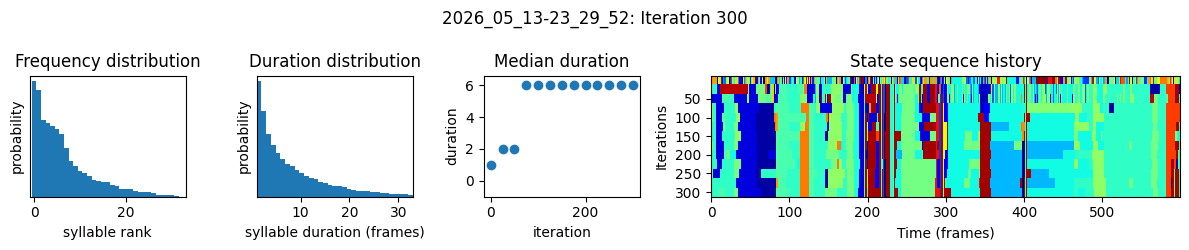

 18%|█████▍                        | 50/276 [1:00:37<4:17:13, 68.29s/it]

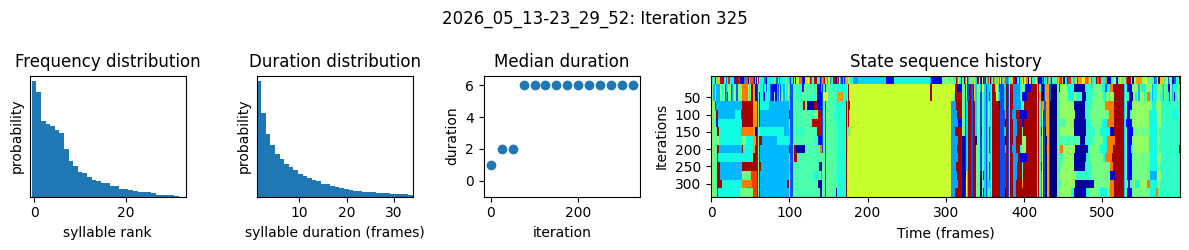

 27%|████████▏                     | 75/276 [1:31:40<4:14:33, 75.99s/it]

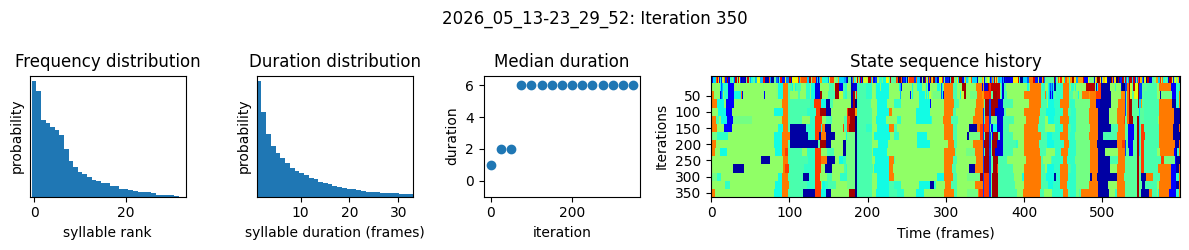

 36%|██████████▌                  | 100/276 [2:03:35<3:43:40, 76.25s/it]

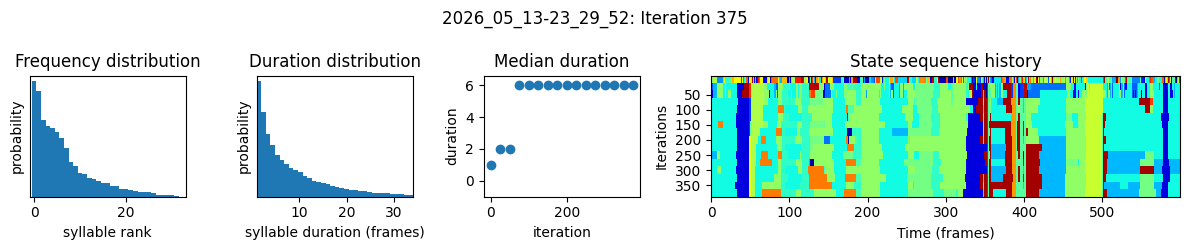

 45%|█████████████▏               | 125/276 [2:35:13<3:11:04, 75.93s/it]

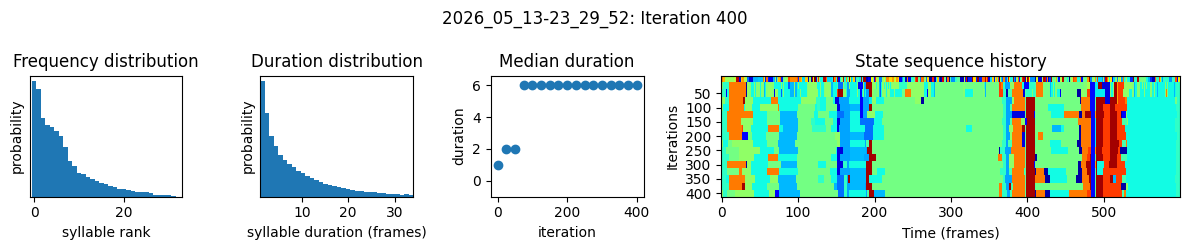

 54%|███████████████▊             | 150/276 [3:05:51<2:19:53, 66.62s/it]

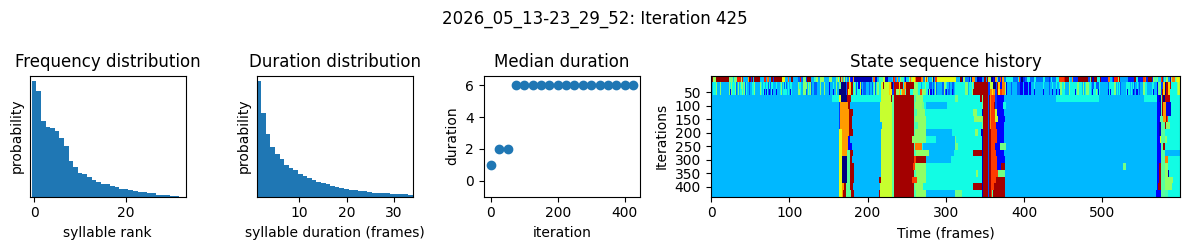

 63%|██████████████████▍          | 175/276 [3:33:06<1:49:58, 65.33s/it]

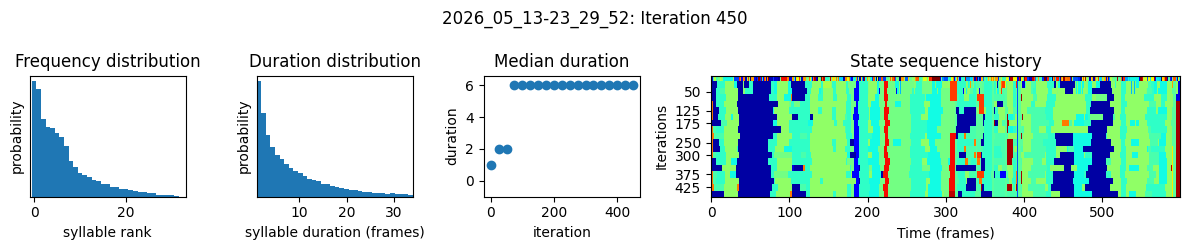

 72%|█████████████████████        | 200/276 [4:00:17<1:22:26, 65.09s/it]

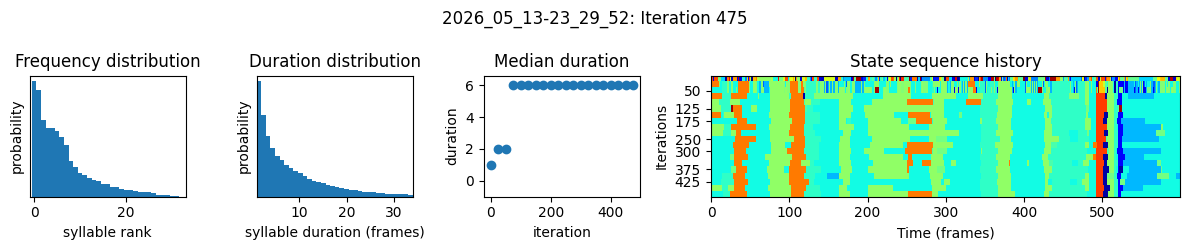

 82%|█████████████████████████▎     | 225/276 [4:27:30<55:24, 65.18s/it]

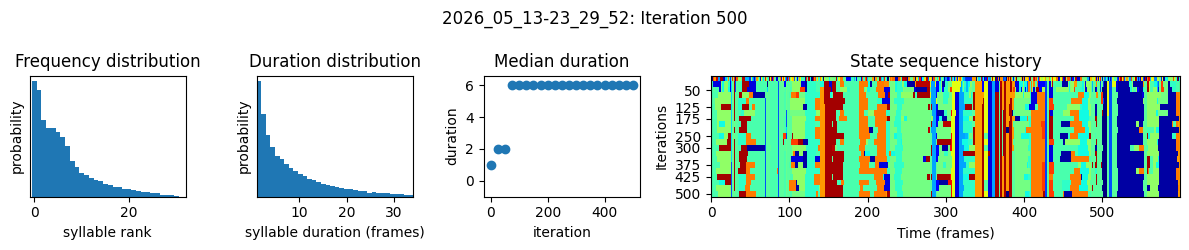

 91%|████████████████████████████   | 250/276 [4:54:47<28:44, 66.32s/it]

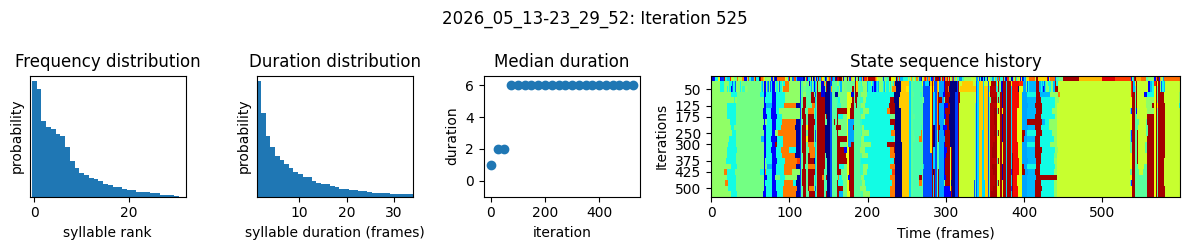

100%|██████████████████████████████▉| 275/276 [5:23:37<01:09, 69.89s/it]

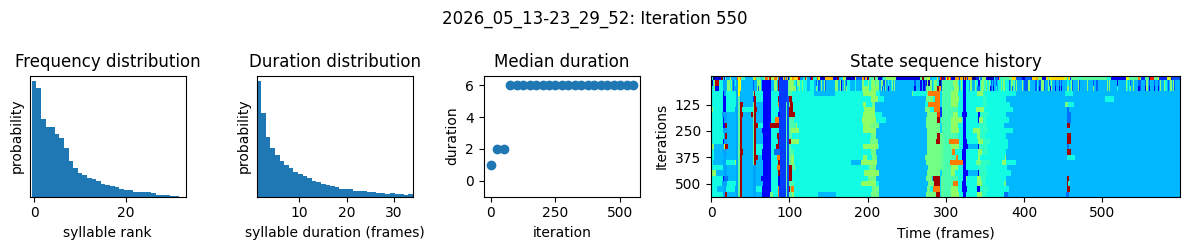

100%|███████████████████████████████| 276/276 [5:24:47<00:00, 70.61s/it]

Done: states60_kappa_1e-5 2026_05_13-23_29_52


In [ ]:
import keypoint_moseq as kpms
from pathlib import Path

# Resume settings
label = "states60_kappa_1e-5"
model_name = None  # set this to a specific run folder if you know it, else latest run is used
ar_only_kappa = 1e5
full_kappa = 1e5
num_ar_iters = 50
num_full_iters = 500
target_iter = num_ar_iters + num_full_iters

project_path = Path(project_dir)

# If no run name is provided, pick the most recently modified timestamped run folder
if model_name is None:
    run_dirs = sorted(
        [p for p in project_path.iterdir() if p.is_dir() and p.name[:4].isdigit()],
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )
    if not run_dirs:
        raise FileNotFoundError(f"No run folders found in {project_path}")
    model_name = run_dirs[0].name

print(f"Resuming {label} from run: {model_name}")

model, data_ckpt, metadata_ckpt, current_iter = kpms.load_checkpoint(
    str(project_path),
    model_name,
)

print(f"Current iteration: {current_iter} / {target_iter}")

if current_iter < num_ar_iters:
    print(f"Continuing AR-only phase to iteration {num_ar_iters}")
    model = kpms.update_hypparams(model, kappa=ar_only_kappa)
    model = kpms.fit_model(
        model,
        data_ckpt,
        metadata_ckpt,
        str(project_path),
        model_name,
        ar_only=True,
        start_iter=current_iter,
        num_iters=num_ar_iters,
    )[0]

    model, data_ckpt, metadata_ckpt, current_iter = kpms.load_checkpoint(
        str(project_path),
        model_name,
    )
    print(f"Reached iteration {current_iter}")

if current_iter < target_iter:
    print(f"Continuing full model phase to iteration {target_iter}")
    model = kpms.update_hypparams(model, kappa=full_kappa)
    model = kpms.fit_model(
        model,
        data_ckpt,
        metadata_ckpt,
        str(project_path),
        model_name,
        ar_only=False,
        start_iter=current_iter,
        num_iters=target_iter,
    )[0]
else:
    print("Run already reached target_iter")
                                                                                                                                                                              
print("Done:", label, model_name)


Outputs will be saved to c:\Users\alber\OneDrive\Documents\GitHub\Fibe
r_Photometry_revisions\Pose_Tracking\keypoint_moseq_project_home_cage\
2026_05_13-23_29_52


 49%|█████████████████▏                 | 25/51 [03:16<03:20,  7.71s/it]

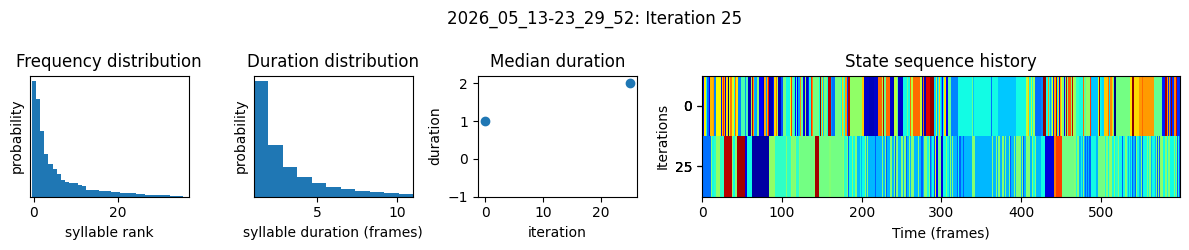

 98%|██████████████████████████████████▎| 50/51 [06:30<00:07,  7.69s/it]

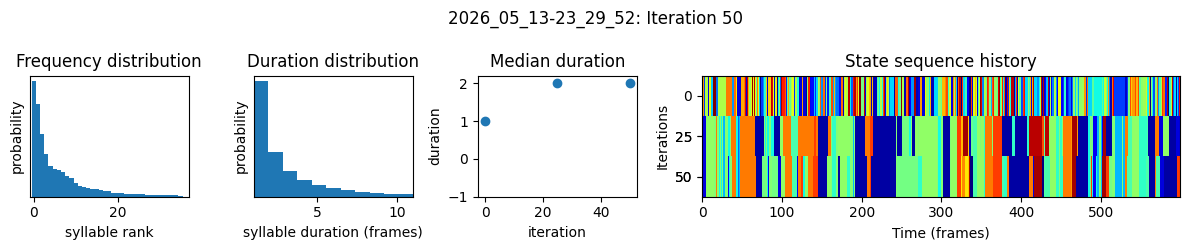

100%|███████████████████████████████████| 51/51 [06:39<00:00,  7.83s/it]


Outputs will be saved to c:\Users\alber\OneDrive\Documents\GitHub\Fibe
r_Photometry_revisions\Pose_Tracking\keypoint_moseq_project_home_cage\
2026_05_13-23_29_52


  5%|█▌                             | 25/501 [31:31<10:00:42, 75.72s/it]

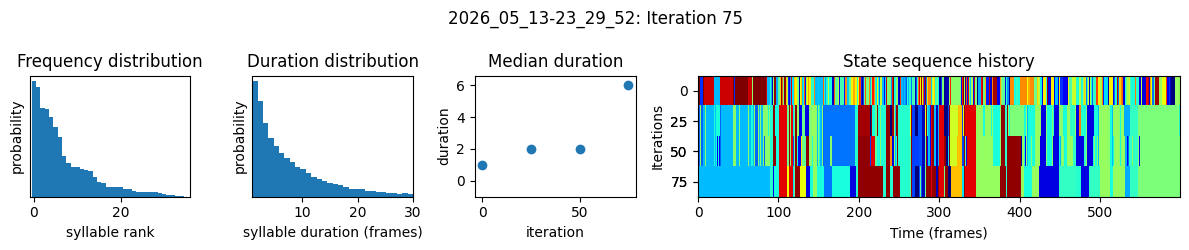

 10%|██▉                           | 50/501 [1:03:05<9:29:06, 75.71s/it]

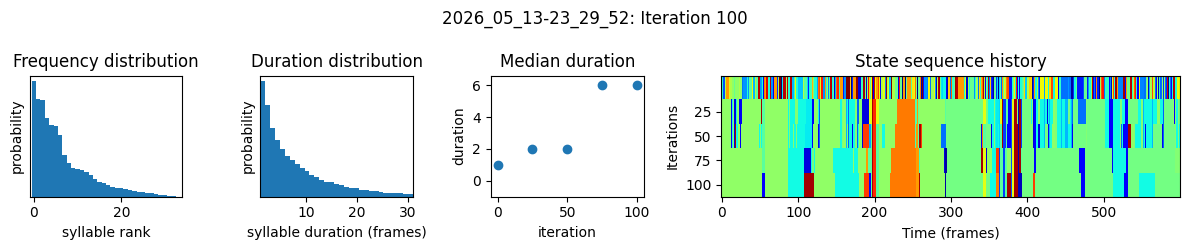

 15%|████▍                         | 75/501 [1:34:44<8:56:58, 75.63s/it]

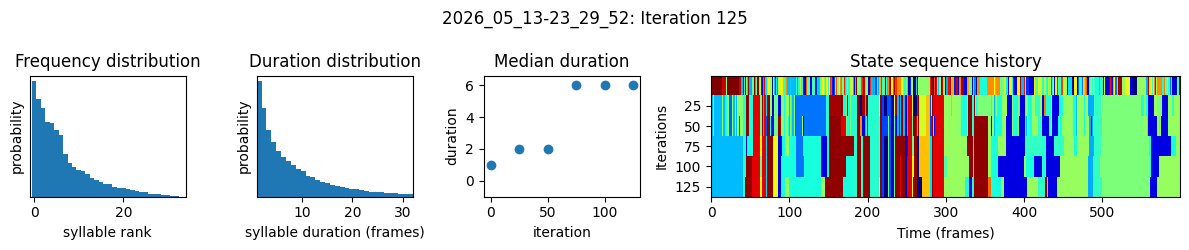

 20%|█████▊                       | 100/501 [2:05:41<7:51:00, 70.47s/it]

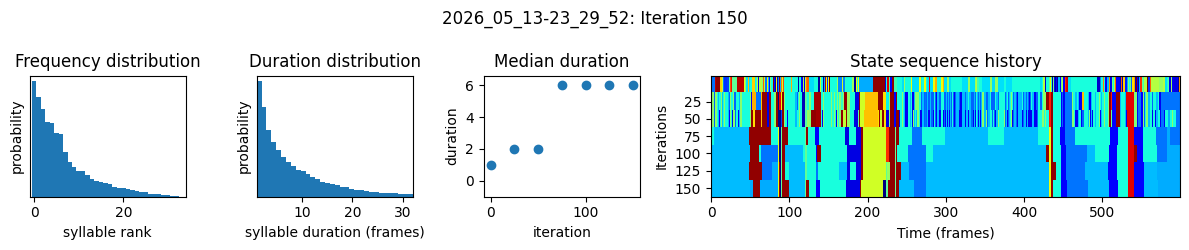

 25%|███████▏                     | 125/501 [2:35:00<7:20:04, 70.22s/it]

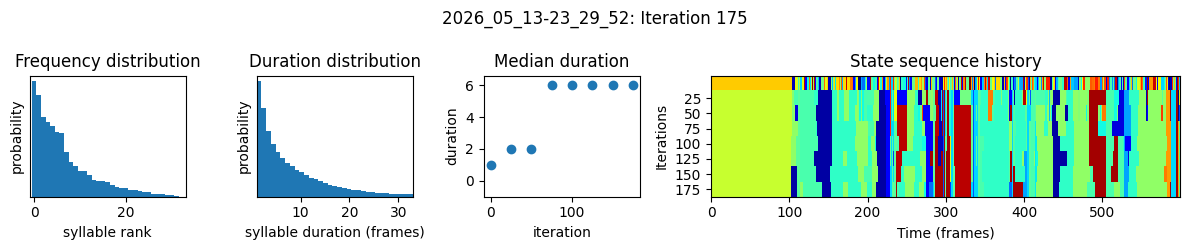

 30%|████████▋                    | 150/501 [3:04:08<6:47:53, 69.72s/it]

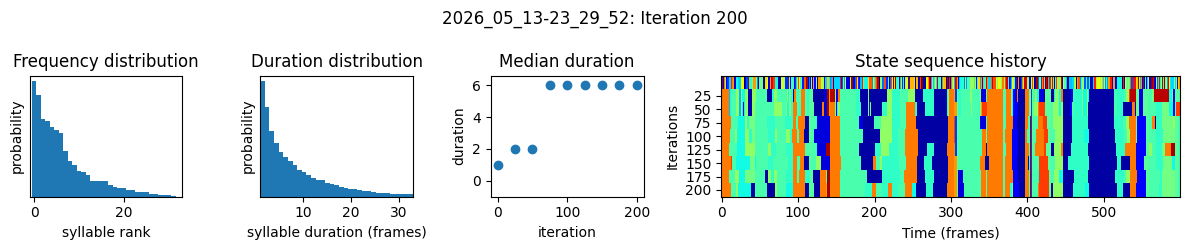

 35%|██████████▏                  | 175/501 [3:33:12<6:20:00, 69.94s/it]

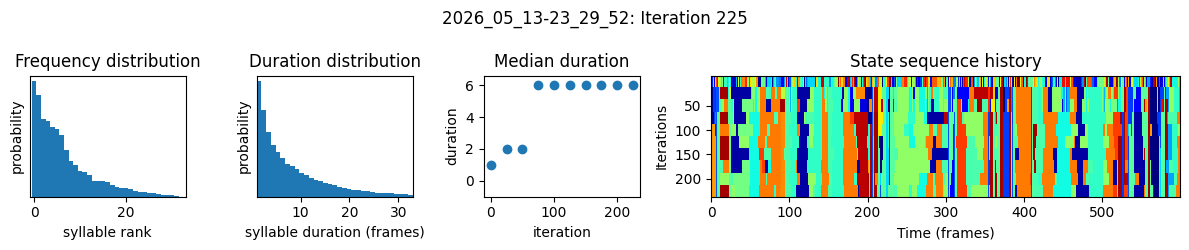

 40%|███████████▌                 | 200/501 [4:02:24<5:53:50, 70.53s/it]

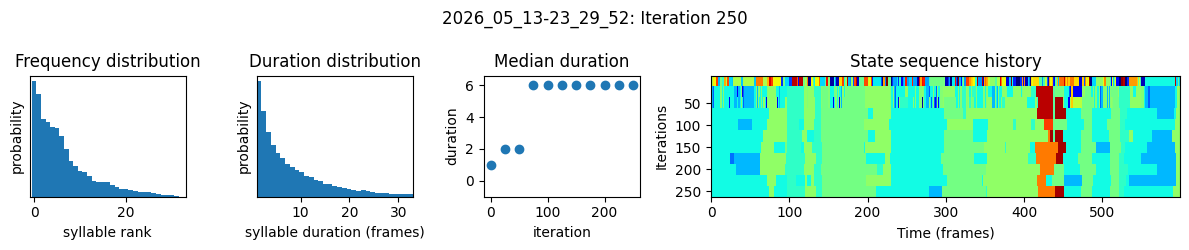

 45%|█████████████                | 225/501 [4:31:46<5:24:14, 70.49s/it]

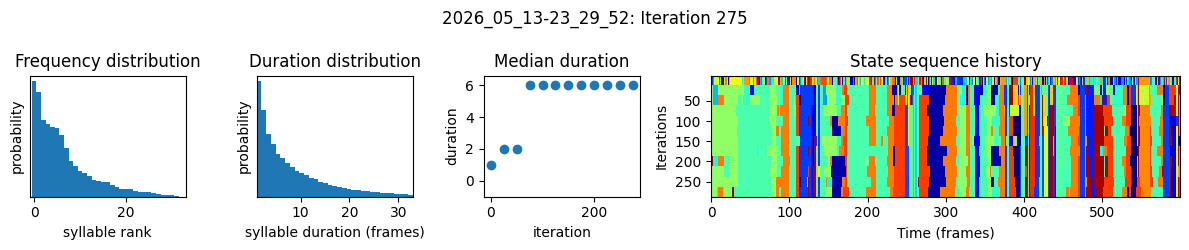

 50%|██████████████▍              | 249/501 [4:59:57<4:56:20, 70.56s/it]

In [ ]:
import keypoint_moseq as kpms

# This notebook builds and loads only valid-frame-filtered inputs via
# home_cage_kpms_inputs_valid_frames.pkl, so this run uses valid frames only.
label = "states60_kappa_1e-5"
model_name = None            # use None if it never started; otherwise set its run folder name
ar_only_kappa = 1e5
full_kappa = 1e5
num_states = 60

num_ar_iters = 50
num_full_iters = 500
target_iter = num_ar_iters + num_full_iters

kpms.update_config(str(project_dir), num_states=num_states)
config = kpms.load_config(str(project_dir))

if model_name is None:
    # never started: begin fresh
    model = kpms.init_model(data, pca=pca, **config)
    model = kpms.update_hypparams(model, kappa=ar_only_kappa)
    model, model_name = kpms.fit_model(
        model,
        data,
        metadata,
        str(project_dir),
        model_name=None,
        ar_only=True,
        num_iters=num_ar_iters,
    )

# resume from latest checkpoint, whether AR-only just finished or full fit crashed
model, data_ckpt, metadata_ckpt, current_iter = kpms.load_checkpoint(
    str(project_dir),
    model_name,
)

if current_iter < num_ar_iters:
    # still in AR-only phase
    model = kpms.fit_model(
        model,
        data_ckpt,
        metadata_ckpt,
        str(project_dir),
        model_name,
        ar_only=True,
        start_iter=current_iter,
        num_iters=num_ar_iters,
    )[0]

    model, data_ckpt, metadata_ckpt, current_iter = kpms.load_checkpoint(
        str(project_dir),
        model_name,
    )

if current_iter < target_iter:
    # continue full model phase
    model = kpms.update_hypparams(model, kappa=full_kappa)
    model = kpms.fit_model(
        model,
        data_ckpt,
        metadata_ckpt,
        str(project_dir),
        model_name,
        ar_only=False,
        start_iter=current_iter,
        num_iters=target_iter,
    )[0]

print(label, model_name)


Training kappa_1e3 with ar_only_kappa=1e+05 and full_kappa=1e+03
Outputs will be saved to c:\Users\alber\OneDrive\Documents\GitHub\Fibe
r_Photometry_revisions\Pose_Tracking\keypoint_moseq_project_home_cage\
2026_05_13-07_32_28


 49%|█████████████████▏                 | 25/51 [04:55<05:14, 12.11s/it]

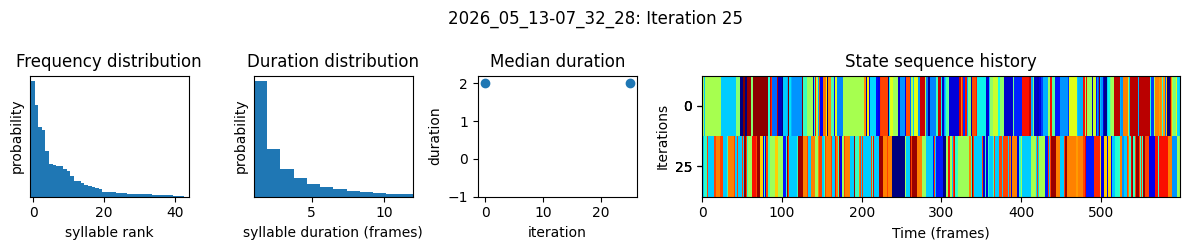

 98%|██████████████████████████████████▎| 50/51 [09:29<00:10, 10.79s/it]

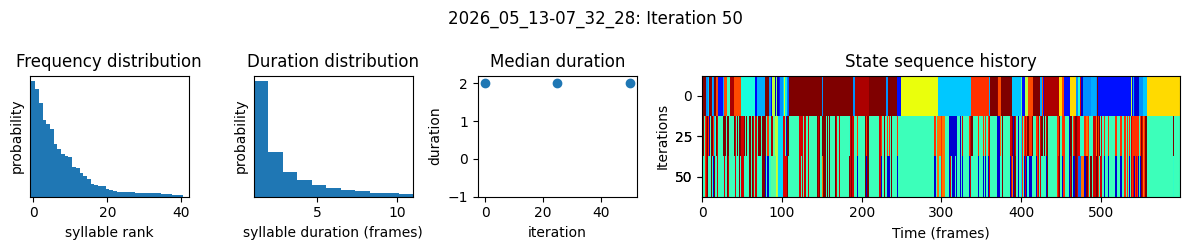

100%|███████████████████████████████████| 51/51 [09:40<00:00, 11.38s/it]


Outputs will be saved to c:\Users\alber\OneDrive\Documents\GitHub\Fibe
r_Photometry_revisions\Pose_Tracking\keypoint_moseq_project_home_cage\
2026_05_13-07_32_28


 12%|███▉                            | 25/201 [35:11<4:09:40, 85.12s/it]

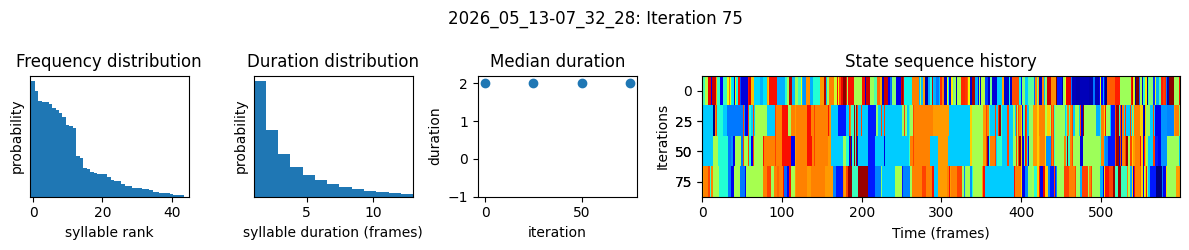

 25%|███████▍                      | 50/201 [1:10:15<3:32:27, 84.42s/it]

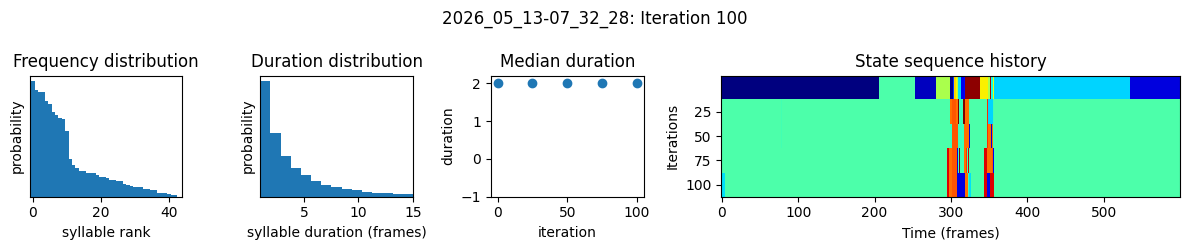

 37%|███████████▏                  | 75/201 [1:44:32<2:50:15, 81.07s/it]

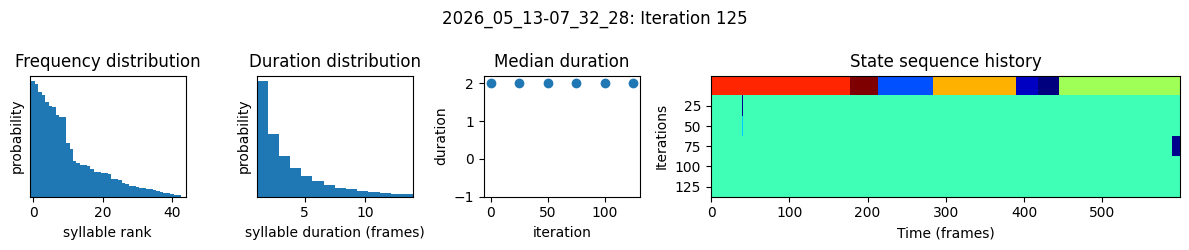

 50%|██████████████▍              | 100/201 [2:19:28<2:34:44, 91.93s/it]

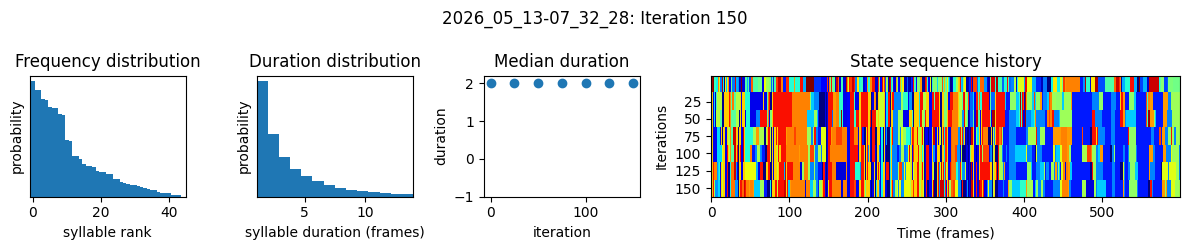

 62%|██████████████████           | 125/201 [2:54:07<1:50:56, 87.59s/it]

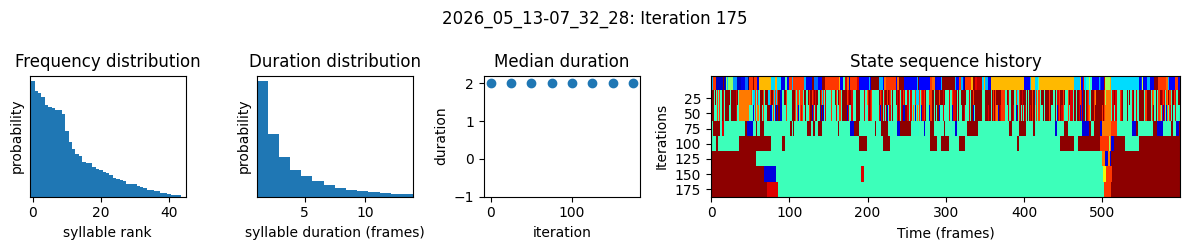

 71%|████████████████████▋        | 143/201 [3:22:01<1:30:31, 93.65s/it]

In [ ]:
# num_ar_iters = 50
# num_full_iters = 200

# # Try a few persistence settings and keep the final selection configurable.
# kappa_sweep = [
#     {"label": "kappa_1e3", "ar_only_kappa": 1e5, "full_kappa": 1e3},
#     {"label": "kappa_1e4", "ar_only_kappa": 1e5, "full_kappa": 1e4},
#     {"label": "kappa_1e5", "ar_only_kappa": 1e5, "full_kappa": 1e5},
# ]

# model_names = {}

# for sweep in kappa_sweep:
#     print(
#         f"Training {sweep['label']} with ar_only_kappa={sweep['ar_only_kappa']:.0e} "
#         f"and full_kappa={sweep['full_kappa']:.0e}"
#     )

#     model = kpms.init_model(data, pca=pca, **config)
#     model = kpms.update_hypparams(model, kappa=sweep["ar_only_kappa"])
#     model, run_model_name = kpms.fit_model(
#         model,
#         data,
#         metadata,
#         str(project_dir),
#         model_name=None,
#         ar_only=True,
#         num_iters=num_ar_iters,
#     )

#     model, data, metadata, current_iter = kpms.load_checkpoint(
#         str(project_dir),
#         run_model_name,
#         iteration=num_ar_iters,
#     )
#     model = kpms.update_hypparams(model, kappa=sweep["full_kappa"])
#     model = kpms.fit_model(
#         model,
#         data,
#         metadata,
#         str(project_dir),
#         run_model_name,
#         ar_only=False,
#         start_iter=current_iter,
#         num_iters=current_iter + num_full_iters,
#     )[0]

#     model_names[sweep["label"]] = run_model_name

# default_kappa_label = "kappa_1e4"
# model_name = model_names[default_kappa_label]
# model_names


## Extract Syllables and Save a Frame Table

In [15]:
kpms.reindex_syllables_in_checkpoint(str(project_dir), model_name)
model, data, metadata, _ = kpms.load_checkpoint(str(project_dir), model_name)
# results = kpms.extract_results(model, metadata, str(project_dir), model_name)
model_name = "2026_05_13-23_29_52"
results = kpms.load_results(str(project_dir), model_name)

kpms.save_results_as_csv(results, str(project_dir), model_name)

syllable_frames = results_to_frame_table(results, metadata_df)
syllable_frames_path = project_dir / model_name / "syllable_frames.csv"
syllable_frames.to_csv(syllable_frames_path, index=False)

print(f"Saved frame table to: {syllable_frames_path}")
syllable_frames.head()


Reindexing:   0%|                    | 0/23 [00:00<?, ?model snapshot/s]

Saving to csv: 100%|████████████████████| 50/50 [00:07<00:00,  6.69it/s]


Saved frame table to: c:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photometry_revisions\Pose_Tracking\keypoint_moseq_project_home_cage\2026_05_13-23_29_52\syllable_frames.csv


,recording_name,frame_index,syllable,time_s,centroid_x,centroid_y,heading,subject_name,trial_name,track_name,source_h5,n_frames,fps,bout_name,bout_start_s,bout_end_s
0,n5_agent,0,28,0.0,203.736220,197.133223,-1.793201,n5,n5-240823-085032,agent,C:\Users\alber\OneDrive\Desktop\PC_Lab\Photome...,15058,10.0,None,None,None
1,n5_agent,1,28,0.1,196.778228,195.179065,-0.351759,n5,n5-240823-085032,agent,C:\Users\alber\OneDrive\Desktop\PC_Lab\Photome...,15058,10.0,None,None,None
2,n5_agent,2,28,0.2,192.914220,193.075127,0.159421,n5,n5-240823-085032,agent,C:\Users\alber\OneDrive\Desktop\PC_Lab\Photome...,15058,10.0,None,None,None
3,n5_agent,3,28,0.3,191.588268,192.025816,-0.813368,n5,n5-240823-085032,agent,C:\Users\alber\OneDrive\Desktop\PC_Lab\Photome...,15058,10.0,None,None,None
4,n5_agent,4,28,0.4,190.082875,192.282703,-0.005084,n5,n5-240823-085032,agent,C:\Users\alber\OneDrive\Desktop\PC_Lab\Photome...,15058,10.0,None,None,None


## Quick Summaries

In [ ]:
syllable_frames.groupby(["track_name", "syllable"]).size().reset_index(name="n_frames").sort_values(
    ["track_name", "n_frames"], ascending=[True, False]
).head(20)


,track_name,syllable,n_frames
35,agent,35,72152
4,agent,4,42069
2,agent,2,39951
0,agent,0,32172
3,agent,3,28983
1,agent,1,28331
9,agent,9,27256
11,agent,11,21868
5,agent,5,21668
10,agent,10,20067


In [ ]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


def generate_selected_trajectory_plots(
    coordinates,
    results,
    output_dir,
    selected_syllables,
    *,
    pre=0.167,
    post=0.5,
    min_frequency=0.0,
    min_duration=3,
    skeleton=None,
    bodyparts=None,
    use_bodyparts=None,
    keypoint_colormap="autumn",
    plot_options=None,
    get_limits_pctl=0,
    padding=None,
    lims=None,
    save_gifs=True,
    save_mp4s=False,
    fps=None,
    density_sample=False,
    sampling_options=None,
):
    if fps is None:
        raise ValueError("fps must be provided")

    plot_options = dict(plot_options or {})
    plot_options.update({"keypoint_colormap": keypoint_colormap})
    padding = padding or {"left": 0.1, "right": 0.1, "top": 0.2, "bottom": 0.2}
    sampling_options = dict(sampling_options or {"n_neighbors": 50})
    skeleton = skeleton or []

    pre_frames = round(pre * fps)
    post_frames = round(post * fps)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    edges = [] if len(skeleton) == 0 else kpms.get_edges(use_bodyparts, skeleton)
    typical_trajectories = kpms.get_typical_trajectories(
        coordinates,
        results,
        pre_frames,
        post_frames,
        min_frequency,
        min_duration,
        bodyparts,
        use_bodyparts,
        density_sample,
        sampling_options,
    )

    requested_syllables = [int(s) for s in selected_syllables]
    syllable_ixs = [s for s in requested_syllables if s in typical_trajectories]
    missing_syllables = [s for s in requested_syllables if s not in typical_trajectories]

    if not syllable_ixs:
        raise ValueError("None of the requested syllables had usable trajectories.")

    titles = [f"Syllable{s}" for s in syllable_ixs]
    Xs = np.stack([typical_trajectories[s] for s in syllable_ixs])

    if Xs.shape[-1] != 2:
        raise ValueError("This helper currently expects 2D trajectories.")

    Xs_2D = Xs * np.array([1, -1])
    if lims is None:
        lims = kpms.get_limits(Xs_2D, pctl=get_limits_pctl, **padding)

    for title, X in zip(titles, Xs_2D):
        fig, ax, rasters = kpms.plot_trajectories(
            [title],
            X[None],
            lims,
            edges=edges,
            return_rasters=(save_gifs or save_mp4s),
            **plot_options,
        )
        fig.savefig(output_dir / f"{title}.pdf")
        plt.close(fig)

        if save_gifs:
            frame_duration = (pre_frames + post_frames) / len(rasters) / fps
            kpms.save_gif(rasters, output_dir / f"{title}.gif", duration=frame_duration)
        if save_mp4s:
            use_fps = len(rasters) / (pre_frames + post_frames) * fps
            kpms.write_video_clip(rasters, output_dir / f"{title}.mp4", fps=use_fps)

    fig, ax, rasters = kpms.plot_trajectories(
        titles,
        Xs_2D,
        lims,
        edges=edges,
        return_rasters=(save_gifs or save_mp4s),
        **plot_options,
    )
    fig.savefig(output_dir / "all_trajectories.pdf")
    plt.show()

    if save_gifs:
        frame_duration = (pre_frames + post_frames) / len(rasters) / fps
        kpms.save_gif(rasters, output_dir / "all_trajectories.gif", duration=frame_duration)
    if save_mp4s:
        use_fps = len(rasters) / (pre_frames + post_frames) * fps
        kpms.write_video_clip(rasters, output_dir / "all_trajectories.mp4", fps=use_fps)

    print(f"Saved {len(syllable_ixs)} syllable plots to {output_dir}")
    if missing_syllables:
        print(f"Skipped {len(missing_syllables)} requested syllables with no usable trajectory: {missing_syllables}")

    return syllable_ixs


In [ ]:
import keypoint_moseq as kpms

project_dir = Path(r"C:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photometry_revisions\Pose_Tracking\keypoint_moseq_project_home_cage")
model_name = "2026_04_28-12_42_32"

config = lambda: kpms.load_config(str(project_dir))

# If needed: reload the exported inputs
payload = load_kpms_inputs(project_dir / "home_cage_kpms_inputs_valid_frames.pkl")
coordinates = payload["coordinates"]

# Load results if they were already saved
results = kpms.load_results(str(project_dir), model_name)


In [ ]:
selected_syllables = list(range(49))

generated_syllables = generate_selected_trajectory_plots(
    coordinates,
    results,
    output_dir=project_dir / model_name / "trajectory_plots_custom",
    selected_syllables=selected_syllables,
    min_frequency=0.0,
    density_sample=False,
    **config(),
)

generated_syllables


TypeError: generate_selected_trajectory_plots() got an unexpected keyword argument 'anterior_bodyparts'